# Newton's Method — A Worked Example

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture *"Newton's method — an example"*
(Week 3 — Optimization in Neural Networks and Newton's Method).

This short lecture **applies** Newton's method to minimize the function from the
gradient-descent lessons,

$$
g(x) = e^{x} - \ln x,
$$

reproducing the iterates $0.097, 0.183, 0.320, 0.477, 0.558, 0.567$ — reaching the
**Omega constant** in just six steps.

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Newton's Method*.

## 1. The setup

Recall from Week 2 that $g(x) = e^{x} - \ln x$ has its minimum at the **Omega constant**
$\approx 0.5671$. To minimize with Newton's method we find the **zero of the derivative**.

So with $f = g'$:

$$
g'(x) = e^{x} - \frac{1}{x}, \qquad
g''(x) = e^{x} + \frac{1}{x^{2}} .
$$

Newton's optimization step is

$$
x_{k+1} = x_k - \frac{g'(x_k)}{g''(x_k)}
        = x_k - \frac{e^{x_k} - 1/x_k}{e^{x_k} + 1/x_k^{2}} .
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g       = lambda x: np.exp(x) - np.log(x)
gprime  = lambda x: np.exp(x) - 1/x          # f  = g'  (we find its zero)
gsecond = lambda x: np.exp(x) + 1/x**2       # f' = g''

# verify the first step by hand, as in the lecture
x0 = 0.05
x1 = x0 - gprime(x0) / gsecond(x0)
print(f"g'(0.05)  = {gprime(x0):.4f}")
print(f"g''(0.05) = {gsecond(x0):.4f}")
print(f"x1 = 0.05 - g'/g'' = {x1:.4f}   (lecture: 0.097)")

g'(0.05)  = -18.9487
g''(0.05) = 401.0513
x1 = 0.05 - g'/g'' = 0.0972   (lecture: 0.097)


## 2. Iterating from $x_0 = 0.05$

The lecture tabulates six iterations. Let's reproduce them.

In [2]:
def newton_optimize(gprime, gsecond, x0, n_iter=6):
    x = float(x0)
    history = [x]
    for _ in range(n_iter):
        x = x - gprime(x) / gsecond(x)
        history.append(x)
    return np.array(history)

hist = newton_optimize(gprime, gsecond, x0=0.05, n_iter=6)

print(f"{'k':>2} | {'x_k':>10} | {'g(x_k)':>10}")
print("-" * 30)
for k, xk in enumerate(hist):
    print(f"{k:>2} | {xk:>10.4f} | {g(xk):>10.5f}")

print("\nlecture values: 0.05, 0.097, 0.183, 0.320, 0.477, 0.558, 0.567")
print(f"Omega constant (true minimum): 0.5671432904")

 k |        x_k |     g(x_k)
------------------------------
 0 |     0.0500 |    4.04700
 1 |     0.0972 |    3.43263
 2 |     0.1832 |    2.89833
 3 |     0.3205 |    2.51566
 4 |     0.4773 |    2.35133
 5 |     0.5578 |    2.33058
 6 |     0.5671 |    2.33037

lecture values: 0.05, 0.097, 0.183, 0.320, 0.477, 0.558, 0.567
Omega constant (true minimum): 0.5671432904


## 3. Visualizing the steps

**Left:** Newton finding the zero of $g'(x)$ — each tangent crosses the x-axis nearer the
root. **Right:** the iterates descending the curve $g(x)$ to its minimum.

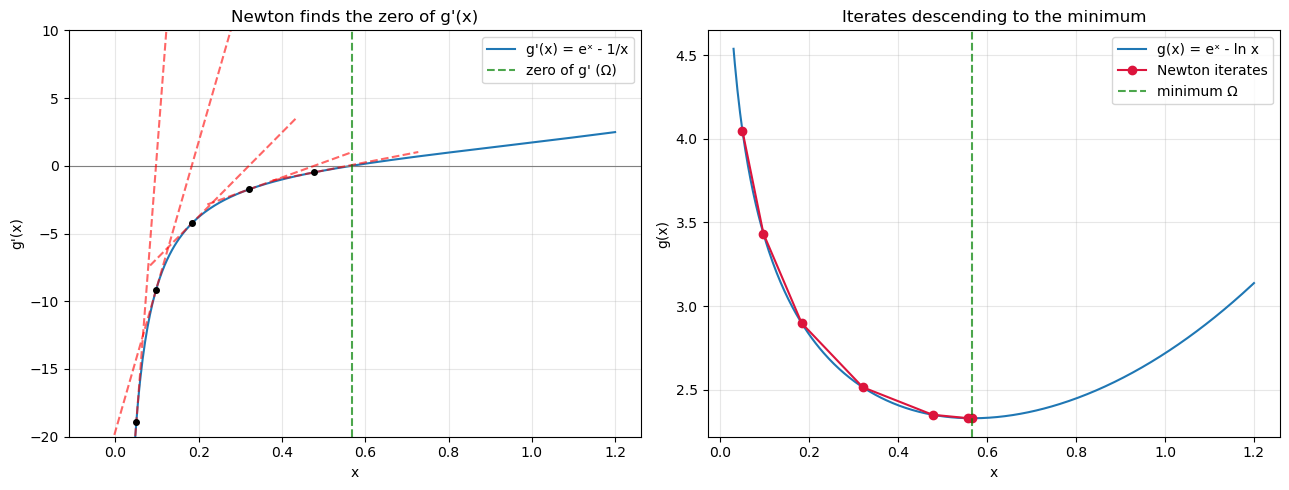

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: root-finding on g'(x)
xs = np.linspace(0.03, 1.2, 400)
axes[0].plot(xs, gprime(xs), label="g'(x) = eˣ - 1/x")
axes[0].axhline(0, color="gray", lw=0.8)
for xk in hist[:5]:
    t = np.linspace(xk - 0.1, xk + 0.25, 10)
    axes[0].plot(t, gprime(xk) + gsecond(xk)*(t - xk), "r--", alpha=0.6)
    axes[0].plot(xk, gprime(xk), "ko", markersize=4)
axes[0].axvline(0.5671432904, color="green", ls="--", alpha=0.7, label="zero of g' (Ω)")
axes[0].set_title("Newton finds the zero of g'(x)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("g'(x)")
axes[0].set_ylim(-20, 10); axes[0].grid(True, alpha=0.3); axes[0].legend()

# right: iterates descending g(x)
axes[1].plot(xs, g(xs), label="g(x) = eˣ - ln x")
axes[1].plot(hist, g(hist), "o-", color="crimson", markersize=6, label="Newton iterates")
axes[1].axvline(0.5671432904, color="green", ls="--", alpha=0.7, label="minimum Ω")
axes[1].set_title("Iterates descending to the minimum")
axes[1].set_xlabel("x"); axes[1].set_ylabel("g(x)")
axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()

## 4. How fast?

> *"With only six iterations, we got really close to the minimum 0.567. Newton's method is
> really, really fast."*

Starting from $x_0 = 0.05$ — quite far from the minimum, where $g''$ is large so the first
steps are small — Newton still lands on the Omega constant in six iterations. Once it gets
near the minimum, convergence is **quadratic** (the correct digits roughly double per
step).

In [4]:
err = np.abs(hist - 0.5671432904)
print(f"{'k':>2} | {'x_k':>10} | {'error |x_k - Ω|':>16}")
for k, (xk, e) in enumerate(zip(hist, err)):
    print(f"{k:>2} | {xk:>10.6f} | {e:>16.2e}")

 k |        x_k |  error |x_k - Ω|
 0 |   0.050000 |         5.17e-01
 1 |   0.097248 |         4.70e-01
 2 |   0.183177 |         3.84e-01
 3 |   0.320520 |         2.47e-01
 4 |   0.477298 |         8.98e-02
 5 |   0.557850 |         9.29e-03
 6 |   0.567060 |         8.34e-05


## 5. Exercises

### Basic
1. Write $g'(x)$ and $g''(x)$ for $g(x) = e^{x} - \ln x$.
2. Write the Newton optimization step for this $g$.

### Intermediate
3. Reproduce $x_1$ from $x_0 = 0.05$ by hand and check it equals $\approx 0.097$.
4. Run Newton's method from $x_0 = 1.0$ instead. How many steps to reach $0.5671$?

### Advanced
5. Compare the number of steps Newton needs from $x_0 = 0.05$ versus how many gradient
   descent needs (from the Week 2 lecture, hundreds). Why the difference?
6. Compute the error $|x_k - \Omega|$ at each step and identify where convergence becomes
   quadratic.

## 6. Solutions / Checks

In [5]:
# 3.
x1 = 0.05 - gprime(0.05)/gsecond(0.05)
print(f"3. x1 = {x1:.4f} (≈ 0.097)")

# 4. from x0=1.0
h1 = [1.0]
while abs(h1[-1] - 0.5671432904) > 1e-9:
    h1.append(h1[-1] - gprime(h1[-1])/gsecond(h1[-1]))
print(f"4. from x0=1.0: {len(h1)-1} steps to reach Ω (x={h1[-1]:.7f})")

print("1. g'(x)=eˣ-1/x,  g''(x)=eˣ+1/x²")
print("2. x_{k+1} = x_k - (eˣ - 1/x)/(eˣ + 1/x²)")
print("5. Newton uses curvature (g'') to size each step, so it needs ~6 steps vs hundreds "
      "for gradient descent's fixed-rate steps.")
print("6. error drops slowly at first (far start) then roughly squares each step near Ω "
      "-> quadratic convergence in the last few iterations.")

3. x1 = 0.0972 (≈ 0.097)
4. from x0=1.0: 4 steps to reach Ω (x=0.5671433)
1. g'(x)=eˣ-1/x,  g''(x)=eˣ+1/x²
2. x_{k+1} = x_k - (eˣ - 1/x)/(eˣ + 1/x²)
5. Newton uses curvature (g'') to size each step, so it needs ~6 steps vs hundreds for gradient descent's fixed-rate steps.
6. error drops slowly at first (far start) then roughly squares each step near Ω -> quadratic convergence in the last few iterations.


## 7. Conclusion

- Newton's method minimizes $g(x) = e^{x} - \ln x$ by driving $g'(x)$ to zero, using
  $x_{k+1} = x_k - g'(x_k)/g''(x_k)$.
- From $x_0 = 0.05$ the iterates are $0.097, 0.183, 0.320, 0.477, 0.558, 0.567$ — the Omega
  constant in **six** steps.
- Convergence is very fast (quadratic near the minimum), dramatically beating gradient
  descent on the same function.
- The price is needing the **second derivative** $g''$; in many variables this becomes the
  **Hessian** — the next topic.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/new_02.mp4`), the Coursera *Calculus for Machine Learning and Data Science*
(Week 3) lecture *"Newton's method — an example"*. Key spoken points, lightly cleaned:

> Apply Newton's method to the Week 2 function $g(x) = e^{x} - \ln x$, whose minimum is the
> Omega constant $0.5671$. To minimize, find the zero of the derivative $g'(x) = e^{x} -
> 1/x$; its derivative is $g''(x) = e^{x} + 1/x^{2}$. Starting at $x_0 = 0.05$, Newton's
> step $x_{k+1} = x_k - g'(x_k)/g''(x_k)$ gives $x_1 = 0.097$, then $x_2 = 0.183$, $x_3 =
> 0.320$, $x_4 = 0.477$, $x_5 = 0.558$, and $x_6 = 0.567$. With only six iterations we get
> very close to the minimum — Newton's method is really fast, and it's just a simple step
> iterated many times.